# Speech Emotion Recognition Project 

**Project Title:**  Multi-Modal Speech Emotion Recognition System 

This project will guide you through building a complete speech emotion recognition system using open-source data and the feature extraction techniques we covered previously.

**1. Project Overview**

**Objective:** Build a machine learning system that can classify emotions from speech signals with at least 65% accuracy.

**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)

    - Download from: https://zenodo.org/record/1188976

    - Contains 24 professional actors (12 male, 12 female)

    - 8 emotions: neutral, calm, happy, sad, angry, fearful, disgust, surprised

    - 1440 speech files total

This project provides a comprehensive foundation in speech processing and gives you practical experience with the complete machine learning pipeline from data loading to model deployment.

In [29]:
import os
import librosa
import numpy as np

dataset_path = "Audio_Speech_Actors_01-24/"

# Emotion code mapping 
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Data storage
X, y = [], []

# Loop through each actor folder
for actor_folder in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor_folder)
    if not os.path.isdir(actor_path):
        continue

    # Loop through each WAV file in the actor folder
    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            file_path = os.path.join(actor_path, file)
            
            # Extract emotion code from filename (3rd segment)
            emotion_code = file.split("-")[2]
            emotion_label = emotion_map.get(emotion_code, "unknown")

            # Load audio
            signal, sr = librosa.load(file_path, sr=16000)
            
            X.append(signal)
            y.append(emotion_label)

            print(f"Loaded {file} → {emotion_label}")

print(f"\n Total audio files loaded: {len(X)}")
print(f"Emotions found: {set(y)}")

Loaded 03-01-05-01-02-01-16.wav → angry
Loaded 03-01-06-01-02-02-16.wav → fearful
Loaded 03-01-06-02-01-02-16.wav → fearful
Loaded 03-01-05-02-01-01-16.wav → angry
Loaded 03-01-07-01-01-01-16.wav → disgust
Loaded 03-01-04-01-01-02-16.wav → sad
Loaded 03-01-04-02-02-02-16.wav → sad
Loaded 03-01-07-02-02-01-16.wav → disgust
Loaded 03-01-08-02-02-01-16.wav → surprised
Loaded 03-01-08-01-01-01-16.wav → surprised
Loaded 03-01-03-02-02-02-16.wav → happy
Loaded 03-01-03-01-01-02-16.wav → happy
Loaded 03-01-02-02-01-01-16.wav → calm
Loaded 03-01-01-01-02-02-16.wav → neutral
Loaded 03-01-02-01-02-01-16.wav → calm
Loaded 03-01-03-02-01-01-16.wav → happy
Loaded 03-01-03-01-02-01-16.wav → happy
Loaded 03-01-02-02-02-02-16.wav → calm
Loaded 03-01-02-01-01-02-16.wav → calm
Loaded 03-01-01-01-01-01-16.wav → neutral
Loaded 03-01-06-01-01-01-16.wav → fearful
Loaded 03-01-05-01-01-02-16.wav → angry
Loaded 03-01-05-02-02-02-16.wav → angry
Loaded 03-01-06-02-02-01-16.wav → fearful
Loaded 03-01-04-01-02-01

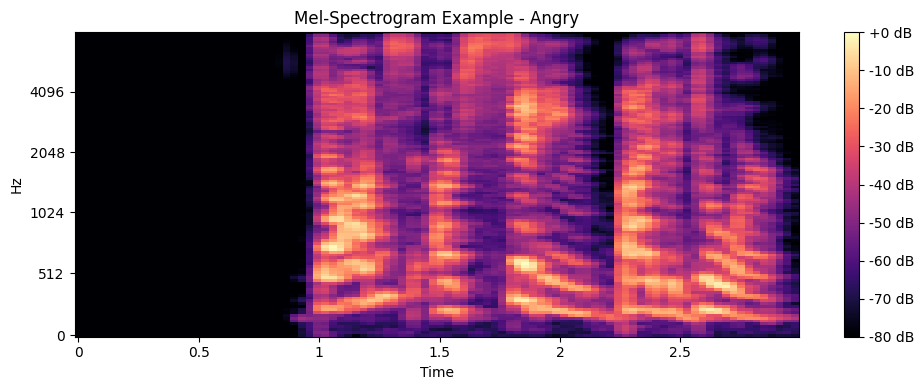

In [30]:
import librosa.display
import matplotlib.pyplot as plt

mel_spectrograms = []

# Loop through all audio signals in X
for i, signal in enumerate(X):
    # Ensure all audio clips have the same length 
    max_length = 16000 * 3  # 3 seconds at 16kHz
    if len(signal) > max_length:
        signal = signal[:max_length]
    else:
        signal = np.pad(signal, (0, max_length - len(signal)))

    # Convert the waveform into a Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=signal, 
        sr=16000,           # sampling rate
        n_fft=2048,         # length of the FFT window
        hop_length=512,     # step size between successive frames
        n_mels=128          # number of Mel bands (height of the "image")
    )

    # Convert from power (amplitude squared) to decibels for better visual scaling
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    mel_spectrograms.append(mel_spec_db)

    # Visualize the first one for inspection
    if i == 0:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(mel_spec_db, sr=16000, hop_length=512, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Mel-Spectrogram Example - {y[i].capitalize()}")
        plt.tight_layout()
        plt.show()

In [31]:
mfcc_features = []
chroma_features = []
zcr_features = []

# Loop through your loaded audio files
for i, signal in enumerate(X):
    # Ensure consistent duration
    max_length = 16000 * 3  # 3 seconds
    if len(signal) > max_length:
        signal = signal[:max_length]
    else:
        signal = np.pad(signal, (0, max_length - len(signal)))

    #MFCC
    mfcc = librosa.feature.mfcc(y=signal, sr=16000, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)  # Take mean across time
    mfcc_features.append(mfcc_mean)

    # Chromagram 
    stft = np.abs(librosa.stft(signal))  # Short-time Fourier transform
    chroma = librosa.feature.chroma_stft(S=stft, sr=16000)
    chroma_mean = np.mean(chroma.T, axis=0)
    chroma_features.append(chroma_mean)

    # Zero Crossing Rate 
    zcr = librosa.feature.zero_crossing_rate(signal)
    zcr_mean = np.mean(zcr)
    zcr_features.append(zcr_mean)

# Convert to NumPy arrays
mfcc_features = np.array(mfcc_features)
chroma_features = np.array(chroma_features)
zcr_features = np.array(zcr_features)

# Concatenate all features into a single array per sample
combined_features = np.concatenate(
    [mfcc_features, chroma_features, zcr_features.reshape(-1, 1)], axis=1
)

print("MFCC shape:", mfcc_features.shape)
print("Chroma shape:", chroma_features.shape)
print("ZCR shape:", np.array(zcr_features).shape)
print("Combined feature vector shape:", combined_features.shape)

MFCC shape: (1440, 40)
Chroma shape: (1440, 12)
ZCR shape: (1440,)
Combined feature vector shape: (1440, 53)


In [33]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Option 1️: StandardScaler (mean = 0, std = 1)
scaler = StandardScaler()
normalized_features = scaler.fit_transform(combined_features)

# Option 2️: MinMaxScaler (scale to 0–1 range)
# scaler = MinMaxScaler()
# normalized_features = scaler.fit_transform(combined_features)

print("Before normalization:")
print("Mean:", np.mean(combined_features, axis=0)[:5])
print("Std:", np.std(combined_features, axis=0)[:5])

print("\nAfter normalization:")
print("Mean:", np.mean(normalized_features, axis=0)[:5])
print("Std:", np.std(normalized_features, axis=0)[:5])

print("\nNormalized feature shape:", normalized_features.shape)

Before normalization:
Mean: [-541.47689871   47.05154359   -9.29769277   10.06519662   -8.05935527]
Std: [106.67386228  17.97939551  14.30430891   9.89588587  10.03460145]

After normalization:
Mean: [ 7.40148683e-17  1.02387234e-16 -2.28212511e-17 -8.63506797e-17
  1.19773019e-16]
Std: [1. 1. 1. 1. 1.]

Normalized feature shape: (1440, 53)


In [34]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
encoder = LabelEncoder()

# Fit and transform the labels
y_encoded = encoder.fit_transform(y)

# Convert to numpy array for model compatibility
y_encoded = np.array(y_encoded)

# Print some info
print("Original labels:", y[:10])
print("Encoded labels:", y_encoded[:10])
print("Class mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

Original labels: ['angry', 'fearful', 'fearful', 'angry', 'disgust', 'sad', 'sad', 'disgust', 'surprised', 'surprised']
Encoded labels: [0 3 3 0 2 6 6 2 7 7]
Class mapping: {np.str_('angry'): np.int64(0), np.str_('calm'): np.int64(1), np.str_('disgust'): np.int64(2), np.str_('fearful'): np.int64(3), np.str_('happy'): np.int64(4), np.str_('neutral'): np.int64(5), np.str_('sad'): np.int64(6), np.str_('surprised'): np.int64(7)}


In [36]:
print(type(normalized_features))
print("Shape of combined_features:", normalized_features.shape)
print("Example feature vector:\n", normalized_features[0])

<class 'numpy.ndarray'>
Shape of combined_features: (1440, 53)
Example feature vector:
 [ 0.64485482 -0.63540859  0.19133084 -1.30157464 -0.89048849 -0.35257489
 -0.72996685 -1.30878067  0.05238302 -0.84871627 -0.83298806 -0.32908364
 -1.18289319 -1.31564544 -0.27971213 -0.55919874 -2.19193245 -0.17773347
 -1.09211236  0.33442937 -0.3195531   0.36441673 -1.41417361 -0.07150447
 -1.25938938 -0.27714373  1.06094513  1.4117043   0.92506791 -0.35190568
 -0.51563487  0.03341366  0.32182895  0.5126469  -0.10677994  0.00406581
  0.51839356  0.55201558  1.03327754 -0.10119193 -2.58749193 -2.37703089
 -1.96519288 -1.54519088 -1.62077027 -0.87594116 -1.53612781 -1.69045142
 -1.01938576 -0.79086845 -0.71250043 -1.53271741 -0.40888644]


In [38]:
print("Mean:", np.mean(normalized_features, axis=0).mean())
print("Std:", np.std(normalized_features, axis=0).mean())

Mean: -9.780412780030976e-17
Std: 0.9999999999999998


In [40]:
X = normalized_features
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [41]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training feature shape: (1152, 53)
Testing feature shape: (288, 53)
Training labels shape: (1152,)
Testing labels shape: (288,)


In [42]:
# Check label distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("\nLabel distribution in training set:")
for u, c in zip(unique_train, counts_train):
    print(f"Class {u}: {c} samples")

print("\nLabel distribution in test set:")
for u, c in zip(unique_test, counts_test):
    print(f"Class {u}: {c} samples")


Label distribution in training set:
Class 0: 154 samples
Class 1: 154 samples
Class 2: 154 samples
Class 3: 153 samples
Class 4: 153 samples
Class 5: 77 samples
Class 6: 154 samples
Class 7: 153 samples

Label distribution in test set:
Class 0: 38 samples
Class 1: 38 samples
Class 2: 38 samples
Class 3: 39 samples
Class 4: 39 samples
Class 5: 19 samples
Class 6: 38 samples
Class 7: 39 samples


In [44]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [ ]:
# compute class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn

classes = np.unique(y_train)              # array([0,1,2,3,4,5,6,7])
class_weights = compute_class_weight(class_weight='balanced',classes=classes,y=y_train)
print("class_weights:", class_weights)

# Convert to tensor for PyTorch (same order as classes)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Use in loss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

class_weights: [0.93506494 0.93506494 0.93506494 0.94117647 0.94117647 1.87012987
 0.93506494 0.94117647]


In [46]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [47]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

In [48]:
#data loading
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [49]:
class FeatureNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FeatureNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [51]:
classes = encoder.classes_
print(classes)

model = FeatureNet(input_dim=53, num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [52]:
EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.4f}")

Epoch [1/30] - Loss: 2.1006
Epoch [2/30] - Loss: 2.0864
Epoch [3/30] - Loss: 2.0664
Epoch [4/30] - Loss: 2.0583
Epoch [5/30] - Loss: 2.0510
Epoch [6/30] - Loss: 2.0382
Epoch [7/30] - Loss: 2.0249
Epoch [8/30] - Loss: 2.0067
Epoch [9/30] - Loss: 1.9935
Epoch [10/30] - Loss: 1.9773
Epoch [11/30] - Loss: 1.9842
Epoch [12/30] - Loss: 1.9491
Epoch [13/30] - Loss: 1.9352
Epoch [14/30] - Loss: 1.9176
Epoch [15/30] - Loss: 1.9018
Epoch [16/30] - Loss: 1.8904
Epoch [17/30] - Loss: 1.8712
Epoch [18/30] - Loss: 1.8552
Epoch [19/30] - Loss: 1.8385
Epoch [20/30] - Loss: 1.8244
Epoch [21/30] - Loss: 1.8135
Epoch [22/30] - Loss: 1.7874
Epoch [23/30] - Loss: 1.7701
Epoch [24/30] - Loss: 1.7569
Epoch [25/30] - Loss: 1.7373
Epoch [26/30] - Loss: 1.7246
Epoch [27/30] - Loss: 1.7213
Epoch [28/30] - Loss: 1.6990
Epoch [29/30] - Loss: 1.6777
Epoch [30/30] - Loss: 1.6674


In [53]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        preds = model(Xb)
        _, predicted = torch.max(preds, 1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.61      0.52        38
           1       0.38      0.68      0.49        38
           2       0.21      0.16      0.18        38
           3       0.47      0.56      0.51        39
           4       0.22      0.05      0.08        39
           5       0.11      0.16      0.13        19
           6       0.17      0.03      0.05        38
           7       0.40      0.54      0.46        39

    accuracy                           0.36       288
   macro avg       0.30      0.35      0.30       288
weighted avg       0.32      0.36      0.32       288

Confusion Matrix:
 [[23  0  6  2  0  0  1  6]
 [ 0 26  0  0  1 10  1  0]
 [ 7  8  6  1  2  5  0  9]
 [ 6  1  2 22  1  0  2  5]
 [ 8  6  5  6  2  3  0  9]
 [ 0 12  3  0  0  3  0  1]
 [ 2 14  1 11  3  5  1  1]
 [ 4  1  5  5  0  2  1 21]]


In [57]:
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix


class FeatureNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FeatureNet, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=128, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        # x shape: (batch, features)
        if len(x.shape) == 2:
            x = x.unsqueeze(1)   # Make it (batch, seq_len=1, features)
        _, (h_n, _) = self.lstm(x)
        x = self.relu(self.fc1(h_n[-1]))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


num_classes = len(classes)  # same as encoder.classes_
model = FeatureNet(input_dim=53, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(model)

FeatureNet(
  (lstm): LSTM(53, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=8, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [58]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

Epoch [1/30] - Loss: 2.0804
Epoch [2/30] - Loss: 2.0759
Epoch [3/30] - Loss: 2.0713
Epoch [4/30] - Loss: 2.0659
Epoch [5/30] - Loss: 2.0565
Epoch [6/30] - Loss: 2.0445
Epoch [7/30] - Loss: 2.0258
Epoch [8/30] - Loss: 1.9999
Epoch [9/30] - Loss: 1.9647
Epoch [10/30] - Loss: 1.9242
Epoch [11/30] - Loss: 1.8918
Epoch [12/30] - Loss: 1.8607
Epoch [13/30] - Loss: 1.8313
Epoch [14/30] - Loss: 1.8079
Epoch [15/30] - Loss: 1.7821
Epoch [16/30] - Loss: 1.7583
Epoch [17/30] - Loss: 1.7332
Epoch [18/30] - Loss: 1.7127
Epoch [19/30] - Loss: 1.6789
Epoch [20/30] - Loss: 1.6689
Epoch [21/30] - Loss: 1.6394
Epoch [22/30] - Loss: 1.6187
Epoch [23/30] - Loss: 1.5964
Epoch [24/30] - Loss: 1.5779
Epoch [25/30] - Loss: 1.5689
Epoch [26/30] - Loss: 1.5349
Epoch [27/30] - Loss: 1.5120
Epoch [28/30] - Loss: 1.4873
Epoch [29/30] - Loss: 1.4742
Epoch [30/30] - Loss: 1.4376


In [59]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.76      0.67        38
           1       0.44      0.63      0.52        38
           2       0.30      0.26      0.28        38
           3       0.45      0.59      0.51        39
           4       0.14      0.03      0.04        39
           5       0.15      0.21      0.18        19
           6       0.33      0.11      0.16        38
           7       0.48      0.69      0.57        39

    accuracy                           0.42       288
   macro avg       0.36      0.41      0.37       288
weighted avg       0.38      0.42      0.38       288

Confusion Matrix:
[[29  1  1  1  2  0  1  3]
 [ 0 24  3  0  0 10  1  0]
 [ 6  3 10  5  2  3  1  8]
 [ 6  0  1 23  1  1  3  4]
 [ 4  3  9  9  1  3  1  9]
 [ 0 10  3  0  0  4  0  2]
 [ 2 13  2  8  1  5  4  3]
 [ 2  0  4  5  0  0  1 27]]


In [60]:
X_mel = np.array(mel_spectrograms)
print(X_mel.shape)

(1440, 128, 94)


In [61]:
X_mel = np.expand_dims(X_mel, axis=1)  # add channel dimension → shape: (N, 1, 128, 94)

In [63]:
print(X_mel.shape, y_encoded.shape)

(1440, 1, 128, 94) (1440,)


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_mel, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [65]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [66]:
import torch.nn as nn
import torch.nn.functional as F

class MelSpectrogramCNN(nn.Module):
    def __init__(self, num_classes):
        super(MelSpectrogramCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * (128 // 8) * (X_train.shape[3] // 8), 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [67]:
model = MelSpectrogramCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(30):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/30] - Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/30] - Loss: 1.9954
Epoch [2/30] - Loss: 1.7642
Epoch [3/30] - Loss: 1.5974
Epoch [4/30] - Loss: 1.4549
Epoch [5/30] - Loss: 1.3502
Epoch [6/30] - Loss: 1.2444
Epoch [7/30] - Loss: 1.1774
Epoch [8/30] - Loss: 1.0768
Epoch [9/30] - Loss: 1.0015
Epoch [10/30] - Loss: 0.9262
Epoch [11/30] - Loss: 0.8647
Epoch [12/30] - Loss: 0.8192
Epoch [13/30] - Loss: 0.7772
Epoch [14/30] - Loss: 0.7274
Epoch [15/30] - Loss: 0.6604
Epoch [16/30] - Loss: 0.6231
Epoch [17/30] - Loss: 0.5855
Epoch [18/30] - Loss: 0.5406
Epoch [19/30] - Loss: 0.5167
Epoch [20/30] - Loss: 0.4743
Epoch [21/30] - Loss: 0.4597
Epoch [22/30] - Loss: 0.4145
Epoch [23/30] - Loss: 0.3759
Epoch [24/30] - Loss: 0.3621
Epoch [25/30] - Loss: 0.3365
Epoch [26/30] - Loss: 0.3252
Epoch [27/30] - Loss: 0.2896
Epoch [28/30] - Loss: 0.2792
Epoch [29/30] - Loss: 0.2602
Epoch [30/30] - Loss: 0.2310


In [68]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81        38
           1       0.67      0.76      0.72        38
           2       0.68      0.55      0.61        38
           3       0.90      0.72      0.80        39
           4       0.77      0.59      0.67        39
           5       0.71      0.63      0.67        19
           6       0.57      0.63      0.60        38
           7       0.68      0.92      0.78        39

    accuracy                           0.71       288
   macro avg       0.72      0.71      0.71       288
weighted avg       0.72      0.71      0.71       288

[[32  0  4  0  1  0  1  0]
 [ 0 29  1  0  0  2  5  1]
 [ 3  2 21  1  0  1  5  5]
 [ 4  0  2 28  2  0  0  3]
 [ 2  0  1  2 23  2  3  6]
 [ 0  2  0  0  0 12  3  2]
 [ 0 10  2  0  2  0 24  0]
 [ 0  0  0  0  2  0  1 36]]
